# California Housing Price Prediction

This notebook loads the California housing dataset, performs exploration, preprocessing, trains several regression models, compares results, and saves the best model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

## Preprocessing

Prepare features and split data for training and testing.

In [ ]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


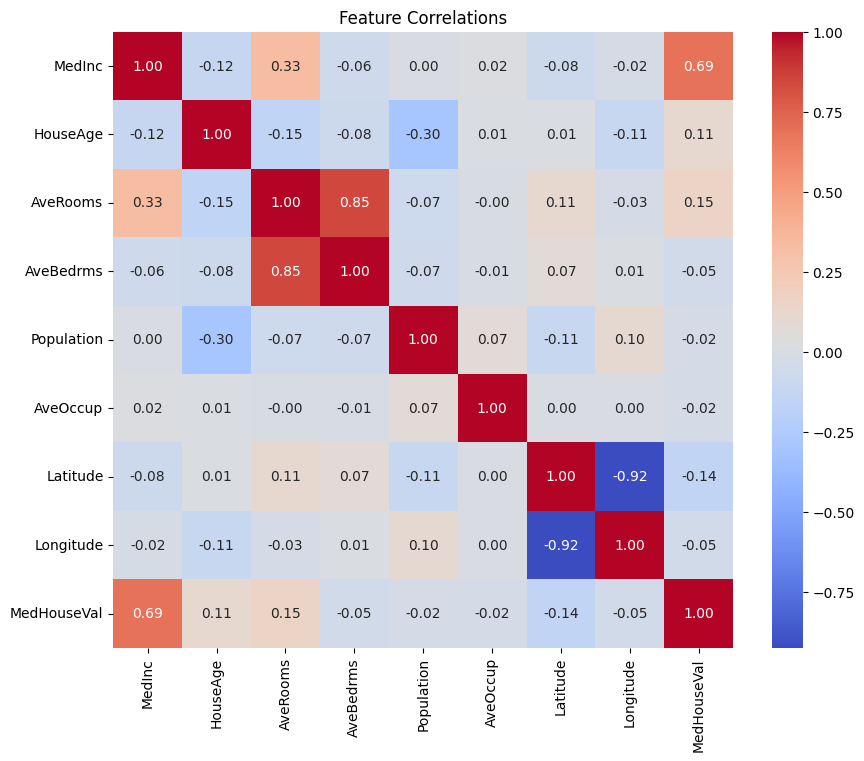

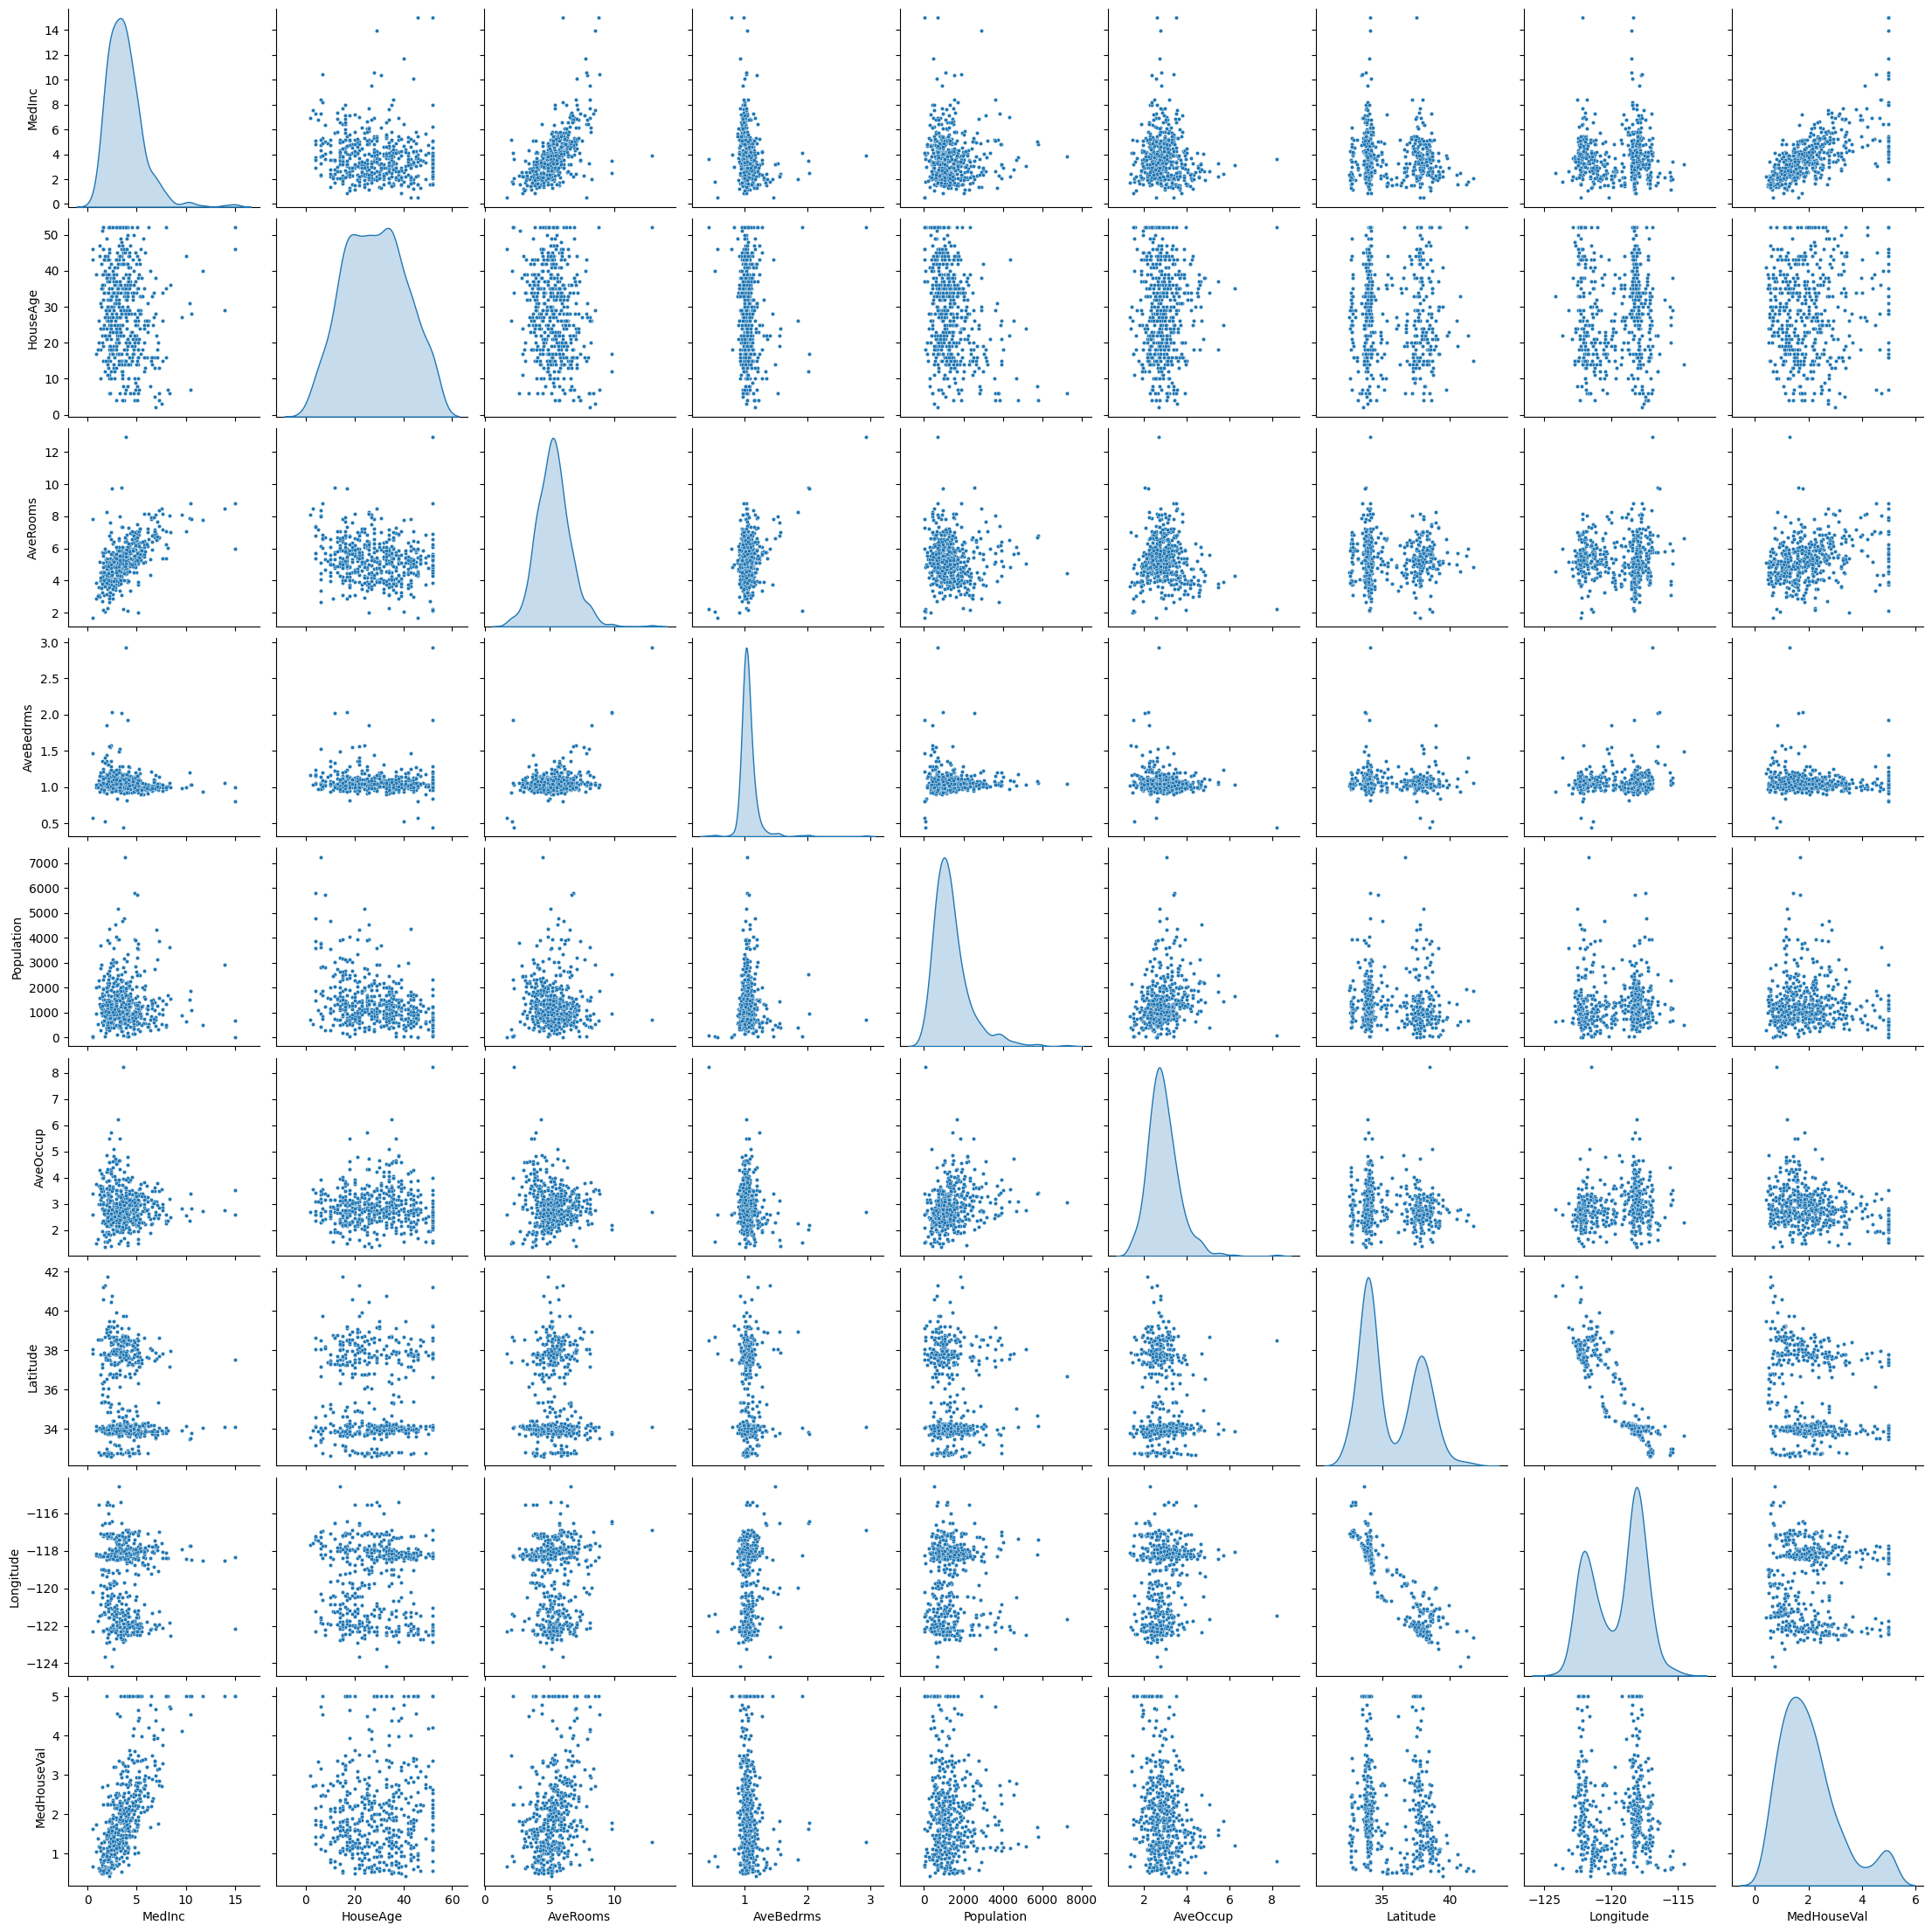

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()
sns.pairplot(df.sample(500), diag_kind="kde", plot_kws={'s':10})
plt.show()

In [ ]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

## Model training

Train a set of regression models and collect metrics.

In [ ]:
models = {
  'LinearRegression': LinearRegression(),
  'Ridge': Ridge(alpha=1.0),
  'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
  'GradientBoosting': GradientBoostingRegressor(random_state=42),
  'SVR': SVR()
}
results = []
for name, model in models.items():
  pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
  scores = cross_val_score(pipe, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
  rmse_cv = np.sqrt(-scores).mean()
  pipe.fit(X_train, y_train)
  preds = pipe.predict(X_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, preds))
  mae_test = mean_absolute_error(y_test, preds)
  r2 = r2_score(y_test, preds)
  results.append((name, rmse_cv, rmse_test, mae_test, r2))
results_df = pd.DataFrame(results, columns=['model','rmse_cv','rmse_test','mae_test','r2'])
results_df = results_df.sort_values('rmse_test')
results_df

,model,rmse_cv,rmse_test,mae_test,r2
2,RandomForest,0.511520,0.505143,0.327425,0.805275
3,GradientBoosting,0.534001,0.542217,0.371650,0.775643
4,SVR,0.592471,0.597498,0.398599,0.727563
1,Ridge,0.720528,0.745557,0.533193,0.575816
0,LinearRegression,0.720527,0.745581,0.533200,0.575788


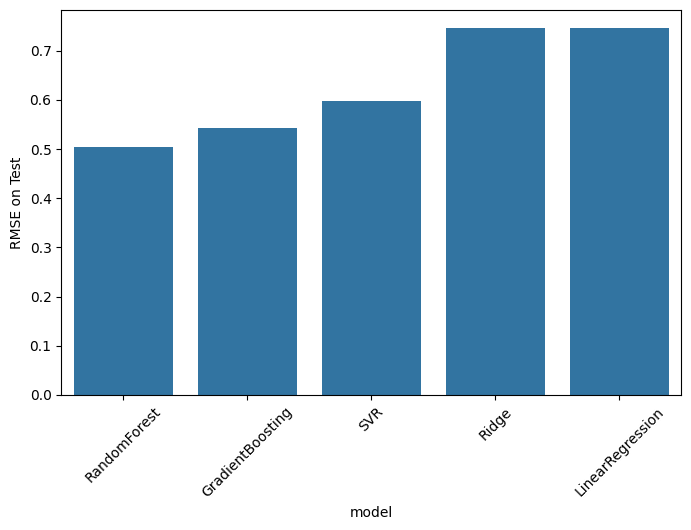

'RandomForest'

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x='model', y='rmse_test', data=results_df)
plt.xticks(rotation=45)
plt.ylabel('RMSE on Test')
plt.show()
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
best_pipe = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
best_pipe.fit(X_train, y_train)
joblib.dump(best_pipe, 'best_model.joblib')
best_model_name

## Results Summary

Models and metrics (sorted by test RMSE):
- `RandomForest`: rmse_cv=0.511520, rmse_test=0.505143, mae_test=0.327425, r2=0.805275
- `GradientBoosting`: rmse_cv=0.534001, rmse_test=0.542217, mae_test=0.371650, r2=0.775643
- `SVR`: rmse_cv=0.592471, rmse_test=0.597498, mae_test=0.398599, r2=0.727563
- `Ridge`: rmse_cv=0.720528, rmse_test=0.745557, mae_test=0.533193, r2=0.575816
- `LinearRegression`: rmse_cv=0.720527, rmse_test=0.745581, mae_test=0.533200, r2=0.575788

Interpretation:
- `RandomForest` is the best-performing model on the test set (lowest RMSE, highest R² ~ 0.805), and its cross-validated RMSE (0.5115) is very close to test RMSE (0.5051), indicating good generalization.
- `GradientBoosting` performs slightly worse than RandomForest but remains competitive, suggesting the problem benefits from nonlinear models that capture interactions.
- `SVR` shows intermediate performance; it is more accurate than linear models but behind tree-based ensembles in this setup.
- `Ridge` and `LinearRegression` perform similarly and substantially worse than the nonlinear models, indicating that a purely linear relationship is insufficient to capture the signal in the features.

Recommendations:
- Focus tuning effort on `RandomForest` and `GradientBoosting` (hyperparameter search with GridSearchCV/RandomizedSearchCV).
- Add feature engineering: spatial features, interactions, and locality aggregates to improve signal for linear and nonlinear models.
- Try ensembling/stacking the top models to reduce error further.
- Validate improvements on a fresh holdout or time-based split before deployment; the current best pipeline is saved as `best_model.joblib`.

Conclusion:
- The RandomForest pipeline currently offers the best accuracy and generalization among the tested models. Pursue tuning and richer features to push performance further.